In [114]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import TypedDict
from dotenv import load_dotenv
import os

Task: We have to create a parallel essay evaluator that evaluate the given eaasy on three diffrent 
parameters and provide structured feedback and score amd then summarise all the score based on the 
three results.

In [115]:
load_dotenv()

True

In [116]:
model=ChatOpenAI(model='gpt-4o-mini')

In [117]:
from typing import Annotated
import operator

In [118]:
## Create State
class EssayState(TypedDict):
    topic: str
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[float], operator.add]
    total_score: float

In [119]:
def generate_essay(state: EssayState):
    ## extarct topic
    topic=state['topic']

    ## form a prompt
    prompt= f"Generate a short essay looks written by class 3rd student on the given topic : {topic}"

    ## generate outline
    essay=model.invoke(prompt).content

    return {"essay": essay}

In [120]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description='Detailed feedback for the essay')
    score: float= Field(description='Score out of 10', ge=0, le=10)
    

In [121]:
structured_model=model.with_structured_output(EvaluationSchema)

In [122]:
def language_eval(state: EssayState):
    ## fetch essay
    essay=state['essay']
    ## prompt to evaluate essay
    prompt=f'Evaluate the language quality of the given essay and score it out of 10. Essay: {essay}'
    output=structured_model.invoke(prompt)

    return {"language_feedback": output.feedback, "individual_scores": [output.score]}

In [123]:
def clarity_eval(state: EssayState):
    ## fetch essay
    essay=state['essay']
    ## prompt to evaluate essay
    prompt=f'Evaluate the clarity of the given essay and score it out of 10. Essay: {essay}'
    output=structured_model.invoke(prompt)
    ## save in state
    return {"clarity_feedback": output.feedback, "individual_scores": [output.score]}

In [124]:
def analysis_eval(state: EssayState):
    ## fetch essay
    essay=state['essay']
    ## prompt to evaluate essay
    prompt=f'Evaluate the analysis of the given essay and score it out of 10. Essay: {essay}'
    output=structured_model.invoke(prompt)

    return {"analysis_feedback": output.feedback, "individual_scores": [output.score]}

In [125]:
def overall_eval(state: EssayState):
    ## fetch essay
    essay=state['essay']
    ## prompt to evaluate essay
    prompt=f'Evaluate the overall quality of the given essay and score it out of 10. Essay: {essay}'
    output=structured_model.invoke(prompt)
    state['total_score']=sum(state['individual_scores'])
    
    return {'overall_feedback': output.feedback, 'total_score': state['total_score']}

In [126]:
graph=StateGraph(EssayState)
## Add Nodes
graph.add_node('generate_essay',generate_essay)
graph.add_node('language_eval', language_eval)
graph.add_node('analysis_eval', analysis_eval)
graph.add_node('clarity_eval', clarity_eval)
graph.add_node('overall_eval', overall_eval)

graph.add_edge(START,'generate_essay')
graph.add_edge('generate_essay', 'language_eval')
graph.add_edge('generate_essay', 'analysis_eval')
graph.add_edge('generate_essay','clarity_eval')
graph.add_edge('language_eval','overall_eval')
graph.add_edge('analysis_eval','overall_eval')
graph.add_edge('clarity_eval','overall_eval')
graph.add_edge('overall_eval',END)

workflow=graph.compile()


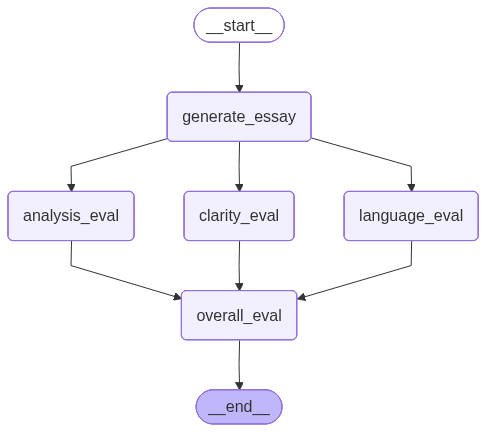

In [127]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [128]:
initial_state={'topic':'Scope of Wind energy in India'}
final_state=workflow.invoke(initial_state)

In [129]:
print(final_state)

{'topic': 'Scope of Wind energy in India', 'essay': '**The Scope of Wind Energy in India**\n\nWind energy is a very important topic in India. It is a clean and renewable source of energy. This means it does not pollute the air and can be used over and over again. In India, we have a lot of wind because we have big, open spaces where the wind blows strongly. This is why wind energy can be very helpful for our country.\n\nFirst, let’s talk about the locations. India has many places like Gujarat, Tamil Nadu, and Maharashtra that are perfect for wind farms. These are big areas with lots of tall wind turbines. The wind turns the blades of these turbines, and they produce electricity. This electricity can be used in our homes, schools, and factories. It reduces the need for fossil fuels, which are harmful to our environment.\n\nNext, wind energy creates jobs. Many people work to build and maintain wind turbines. This means more jobs for engineers, technicians, and workers who help to keep ev

In [130]:
print(final_state['topic'])

Scope of Wind energy in India


In [131]:
print(final_state['essay'])

**The Scope of Wind Energy in India**

Wind energy is a very important topic in India. It is a clean and renewable source of energy. This means it does not pollute the air and can be used over and over again. In India, we have a lot of wind because we have big, open spaces where the wind blows strongly. This is why wind energy can be very helpful for our country.

First, let’s talk about the locations. India has many places like Gujarat, Tamil Nadu, and Maharashtra that are perfect for wind farms. These are big areas with lots of tall wind turbines. The wind turns the blades of these turbines, and they produce electricity. This electricity can be used in our homes, schools, and factories. It reduces the need for fossil fuels, which are harmful to our environment.

Next, wind energy creates jobs. Many people work to build and maintain wind turbines. This means more jobs for engineers, technicians, and workers who help to keep everything running smoothly. As India continues to grow, we n

In [132]:
final_state['total_score']

20.0

In [133]:
final_state['individual_scores']

[6.0, 7.0, 7.0]